In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "D:\EDA projects\student_performance\data\student_performance_4000.csv"
)

df.head()

,student_id,gender,age,study_hours,attendance,previous_score,assignments_completed,sleep_hours,internet_access,parent_education,extra_activities,family_income,class_participation,study_method,stress_level,final_score,performance
0,10001,Female,19,2.1,82.8,66.5,4,6.8,Yes,Graduate,No,Medium,3,Self Study,5,71.0,Good
1,10002,Male,20,4.6,87.1,80.5,6,4.7,Yes,Graduate,No,Medium,2,Self Study,8,70.7,Good
2,10003,Female,16,2.8,88.4,68.9,4,7.0,No,Graduate,Yes,Medium,1,Self Study,3,73.7,Good
3,10004,Female,17,1.2,83.2,51.9,10,NaN,Yes,Graduate,No,Low,2,Online,8,55.2,Average
4,10005,Male,21,3.3,62.2,79.5,4,7.7,Yes,Graduate,No,Medium,10,Self Study,7,77.7,Good


In [2]:
# remove unnecessary columns 

X = df.drop(
    columns=["student_id", "final_score", "performance"]
)

y = df["performance"]

In [3]:
print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['gender', 'age', 'study_hours', 'attendance', 'previous_score',
       'assignments_completed', 'sleep_hours', 'internet_access',
       'parent_education', 'extra_activities', 'family_income',
       'class_participation', 'study_method', 'stress_level'],
      dtype='str')

Target:
performance


In [4]:
# Check missing values in X
X.isnull().sum()

gender                    0
age                       0
study_hours              60
attendance               60
previous_score           60
assignments_completed     0
sleep_hours              60
internet_access           0
parent_education         60
extra_activities          0
family_income             0
class_participation       0
study_method              0
stress_level              0
dtype: int64

In [5]:
# Check missing values in y
y.isnull().sum()

np.int64(60)

In [6]:
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

Missing values in X: 300
Missing values in y: 60


In [7]:
X = X.dropna()
y = y.loc[X.index]   # align target with cleaned features


In [8]:
X = X.fillna(0)   # replace NaNs with 0


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [10]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'study_hours', 'attendance', 'previous_score', 'assignments_completed', 'sleep_hours', 'class_participation', 'stress_level']

Categorical features:
['gender', 'internet_access', 'parent_education', 'extra_activities', 'family_income', 'study_method']


C:\Users\awara\AppData\Local\Temp\ipykernel_6296\345955849.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [11]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [12]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [14]:
print("Missing values in X:")
print(X.isnull().sum())

print("\nTotal missing values in X:")
print(X.isnull().sum().sum())

Missing values in X:
gender                   0
age                      0
study_hours              0
attendance               0
previous_score           0
assignments_completed    0
sleep_hours              0
internet_access          0
parent_education         0
extra_activities         0
family_income            0
class_participation      0
study_method             0
stress_level             0
dtype: int64

Total missing values in X:
0


In [15]:
print("Missing values in y:")
print(y.isnull().sum())

print("\nTotal rows in y:")
print(len(y))

Missing values in y:
57

Total rows in y:
3714


In [16]:
print(df[df["performance"].isnull()])

      student_id  gender  age  study_hours  attendance  previous_score  \
77         10078  Female   17          4.8        67.4            66.2   
102        10103    Male   16          6.9        81.1            73.9   
258        10259    Male   18          7.0        71.9            49.5   
262        10263    Male   20          3.3        65.6            74.3   
468        10469    Male   19          6.1        90.3            87.5   
529        10530    Male   19          1.6        80.0            59.7   
546        10547    Male   19          2.0        92.3            68.5   
606        10607  Female   17          7.9        81.0            70.4   
643        10644    Male   18          5.4        89.2            81.9   
660        10661    Male   21          5.5        85.7            65.7   
671        10672  Female   15          6.3        60.8           100.0   
750        10751    Male   16          3.7        95.4            52.7   
789        10790  Female   17         

In [17]:
df = df.dropna(subset=["performance"])

In [18]:
X = df.drop(
    columns=["student_id", "final_score", "performance"]
)

y = df["performance"]

In [19]:
print("Missing X:", X.isnull().sum().sum())
print("Missing y:", y.isnull().sum())

Missing X: 297
Missing y: 0


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3152, 14)
X_test: (788, 14)
y_train: (3152,)
y_test: (788,)


In [21]:
# Preprocessing

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [22]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()

C:\Users\awara\AppData\Local\Temp\ipykernel_6296\1875100739.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [24]:
# Built ML PIPELINE

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced"
            )
        )
    ]
)

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# Numerical columns
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

# Categorical columns
categorical_features = X.select_dtypes(include="object").columns.tolist()

# Numerical preprocessing
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine both
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

# Complete ML pipeline
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced"
            )
        )
    ]
)

print("Pipeline created successfully!")

Pipeline created successfully!


C:\Users\awara\AppData\Local\Temp\ipykernel_6296\2857165001.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns.tolist()


In [26]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3152, 14)
X_test shape: (788, 14)
y_train shape: (3152,)
y_test shape: (788,)


In [27]:
print("Missing values in X_train:")
print(X_train.isnull().sum().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum().sum())

Missing values in X_train:
229

Missing values in X_test:
68


In [28]:
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [29]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:20])

Predictions generated successfully!
['Good' 'Excellent' 'Good' 'Excellent' 'Good' 'Excellent' 'Excellent'
 'Excellent' 'Excellent' 'Good' 'Good' 'Average' 'Excellent' 'Good'
 'Excellent' 'Good' 'Average' 'Excellent' 'Excellent' 'Excellent']


In [30]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7233502538071066


In [31]:
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

     Average       0.34      0.70      0.46        47
   Excellent       0.88      0.79      0.83       458
        Good       0.63      0.62      0.62       282
        Poor       0.00      0.00      0.00         1

    accuracy                           0.72       788
   macro avg       0.46      0.53      0.48       788
weighted avg       0.76      0.72      0.73       788



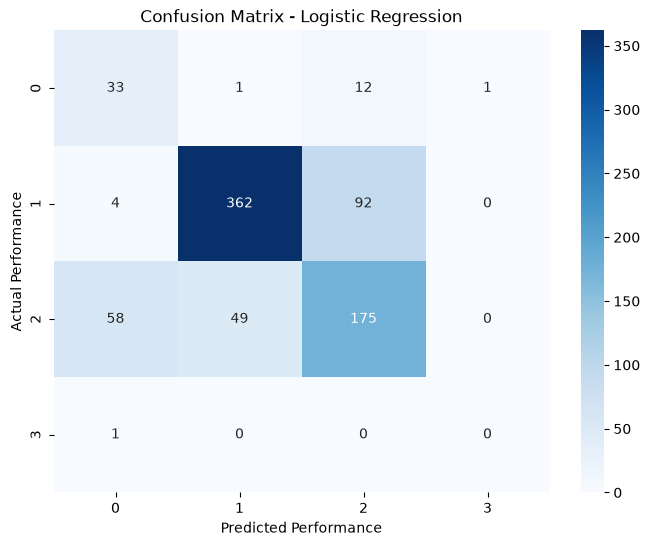

In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Performance")
plt.ylabel("Actual Performance")

plt.show()

In [33]:
# Model ki performance save krne k liye 

logistic_accuracy = accuracy

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.7233502538071066


In [34]:
# second Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

print("Random Forest pipeline created!")

Random Forest pipeline created!


In [35]:
rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [36]:
rf_pred = rf_model.predict(X_test)

print(rf_pred[:20])

['Good' 'Excellent' 'Good' 'Excellent' 'Good' 'Excellent' 'Excellent'
 'Good' 'Excellent' 'Good' 'Good' 'Good' 'Good' 'Good' 'Excellent' 'Good'
 'Good' 'Excellent' 'Excellent' 'Excellent']


In [37]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.75


In [38]:
print(classification_report(
    y_test,
    rf_pred,
    zero_division=0
))

              precision    recall  f1-score   support

     Average       0.53      0.21      0.30        47
   Excellent       0.85      0.81      0.83       458
        Good       0.63      0.74      0.68       282
        Poor       0.00      0.00      0.00         1

    accuracy                           0.75       788
   macro avg       0.50      0.44      0.45       788
weighted avg       0.75      0.75      0.74       788



In [39]:
# Compare both models 

print("Model Comparison")
print("-------------------------")

print(
    "Logistic Regression:",
    round(logistic_accuracy, 4)
)

print(
    "Random Forest:",
    round(rf_accuracy, 4)
)

Model Comparison
-------------------------
Logistic Regression: 0.7234
Random Forest: 0.75


In [40]:
from sklearn.metrics import accuracy_score, f1_score

logistic_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average="macro"
)

print("MODEL COMPARISON")
print("-----------------------------")

print("Logistic Regression")
print("Accuracy:", round(logistic_accuracy, 4))
print("Macro F1:", round(logistic_f1, 4))

print("\nRandom Forest")
print("Accuracy:", round(rf_accuracy, 4))
print("Macro F1:", round(rf_f1, 4))

MODEL COMPARISON
-----------------------------
Logistic Regression
Accuracy: 0.7234
Macro F1: 0.4794

Random Forest
Accuracy: 0.75
Macro F1: 0.4538


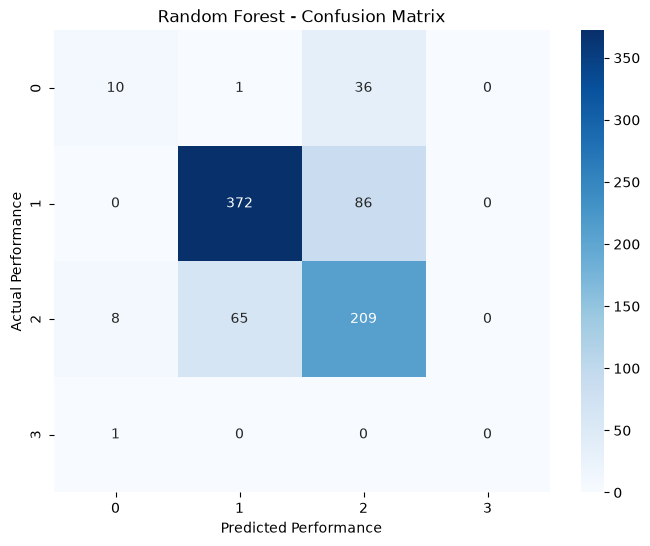

In [41]:
# confusion random forest 

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Performance")
plt.ylabel("Actual Performance")

plt.show()

In [42]:
# Detail random forest detail

print("Random Forest Classification Report")
print("-------------------------------------")

print(
    classification_report(
        y_test,
        rf_pred,
        zero_division=0
    )
)

Random Forest Classification Report
-------------------------------------
              precision    recall  f1-score   support

     Average       0.53      0.21      0.30        47
   Excellent       0.85      0.81      0.83       458
        Good       0.63      0.74      0.68       282
        Poor       0.00      0.00      0.00         1

    accuracy                           0.75       788
   macro avg       0.50      0.44      0.45       788
weighted avg       0.75      0.75      0.74       788



In [43]:
final_model = model
final_model_name = "Logistic Regression"

In [44]:
import joblib

In [45]:
joblib.dump(
    final_model,
    "../models/student_performance_model.pkl"
)

print("Final model saved successfully!")
print("Model:", final_model_name)

Final model saved successfully!
Model: Logistic Regression


In [46]:
# wapis load and test 

loaded_model = joblib.load(
    "../models/student_performance_model.pkl"
)

test_prediction = loaded_model.predict(X_test)

print("Loaded model prediction successful!")
print(test_prediction[:10])

Loaded model prediction successful!
['Good' 'Excellent' 'Good' 'Excellent' 'Good' 'Excellent' 'Excellent'
 'Excellent' 'Excellent' 'Good']
